In [2]:
import pandas as pd
import os

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
PROCESSED_PATH = os.path.join(BASE_DIR, "processed_data")

orders = pd.read_parquet(os.path.join(PROCESSED_PATH, "fact_orders.parquet"))
items = pd.read_parquet(os.path.join(PROCESSED_PATH, "fact_order_items.parquet"))
payments = pd.read_parquet(os.path.join(PROCESSED_PATH, "fact_payments.parquet"))
products = pd.read_parquet(os.path.join(PROCESSED_PATH, "dim_products.parquet"))
customers = pd.read_parquet(os.path.join(PROCESSED_PATH, "dim_customers.parquet"))

In [3]:
items["total_price"] = items["price"] + items["freight"]
items.head()

,order_id,item_number,product_id,seller_id,shipping_limit,price,freight,total_price
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04


In [4]:
df = (
    items
    .merge(orders, on="order_id", how="left")
    .merge(payments, on="order_id", how="left")
)

df.head()

,order_id,item_number,product_id,seller_id,shipping_limit,price,freight,total_price,customer_id,status,purchase_ts,approved_ts,carrier_ts,delivered_ts,estimated_ts,payment_seq,payment_type,installments,value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,1.0,credit_card,2.0,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,1.0,credit_card,3.0,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,1.0,credit_card,5.0,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,1.0,credit_card,2.0,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,1.0,credit_card,3.0,218.04


In [5]:
df["purchase_month"] = df["purchase_ts"].dt.to_period("M").astype(str)
df[["purchase_ts", "purchase_month"]].head()

,purchase_ts,purchase_month
0,2017-09-13 08:59:02,2017-09
1,2017-04-26 10:53:06,2017-04
2,2018-01-14 14:33:31,2018-01
3,2018-08-08 10:00:35,2018-08
4,2017-02-04 13:57:51,2017-02


In [6]:
monthly_revenue = (
    df.groupby("purchase_month")["total_price"]
    .sum()
    .reset_index()
    .sort_values("purchase_month")
)

monthly_revenue

,purchase_month,total_price
0,2016-09,354.75
1,2016-10,58550.03
2,2016-12,19.62
3,2017-01,146455.54
4,2017-02,302230.37
5,2017-03,457782.29
6,2017-04,448742.78
7,2017-05,630089.88
8,2017-06,526495.91
9,2017-07,627312.81


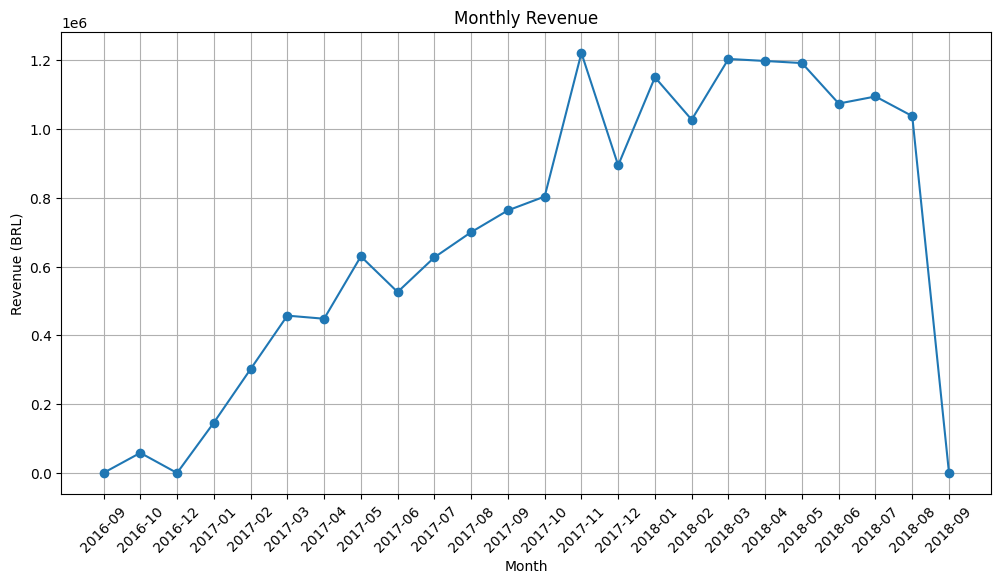

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly_revenue["purchase_month"], monthly_revenue["total_price"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (BRL)")
plt.grid(True)
plt.show()

In [8]:
df = df.merge(products[["product_id", "category"]], on="product_id", how="left")

category_revenue = (
    df.groupby("category")["total_price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue.head()

,category,total_price
0,beleza_saude,1486023.75
1,relogios_presentes,1357478.82
2,cama_mesa_banho,1310284.13
3,esporte_lazer,1198524.35
4,informatica_acessorios,1095456.98


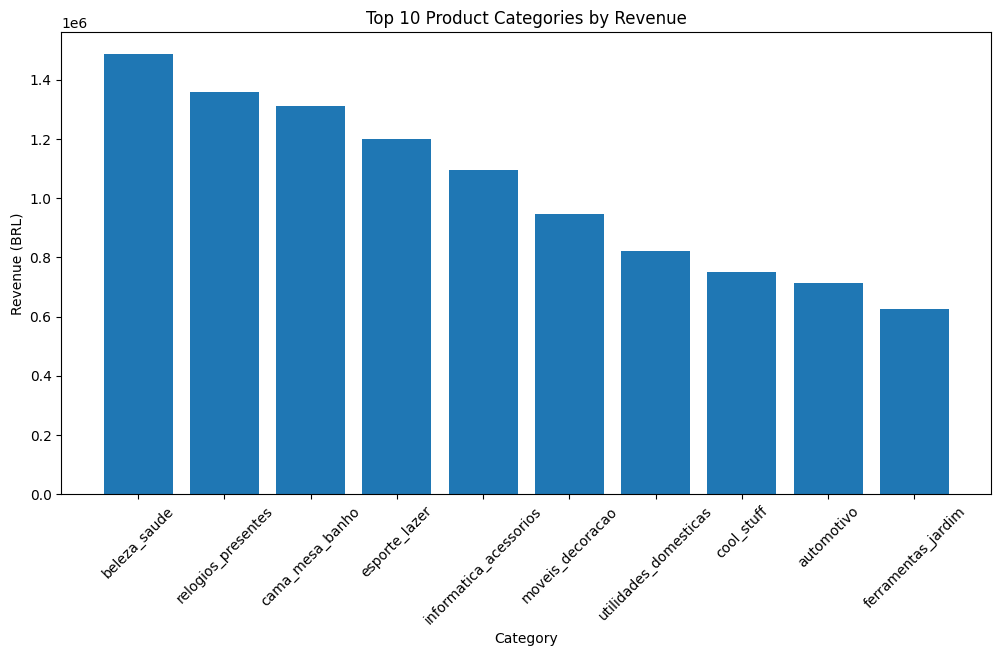

In [9]:
top10 = category_revenue.head(10)

plt.figure(figsize=(12,6))
plt.bar(top10["category"], top10["total_price"])
plt.xticks(rotation=45)
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue (BRL)")
plt.show()

In [10]:
repeat_customers = (
    orders.groupby("customer_id")["order_id"]
    .count()
    .reset_index()
)

repeat_customers["is_repeat"] = repeat_customers["order_id"] > 1

repeat_rate = repeat_customers["is_repeat"].mean()
repeat_rate

np.float64(0.0)

In [11]:
orders["delivery_delay"] = (
    orders["delivered_ts"] - orders["estimated_ts"]
).dt.days

orders["delivery_delay"].describe()

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay, dtype: float64